# The `Cask` Class

The {py:obj}`Cask <snf_simulations.cask.Cask>` class, defined in the {py:obj}`snf_simulations.cask <snf_simulations.cask>` module, is the primary interface for simulating spent nuclear fuel (SNF) casks.

A single `Cask` object represents a single SNF cask, and is built around a {py:obj}`Spectrum <snf_simulations.spec.Spectrum>` object that represents the combined antineutrino spectrum from all isotopes in the cask.

## Creating a `Cask`

In order to simulate a cask of SNF, the key input we need is the mass of each isotope in the cask that contributes to the antineutrino spectrum. This is typically obtained from a reactor simulation using FISPIN, which provides the mass of each isotope in the SNF as a function of the cooling time after being removed from the reactor core.

### Creating a `Cask` directly

The first way to create a `Cask` object is to initialise it by providing a dictionary of isotope masses, where the keys are the isotope names and the values are the masses in kg. For example:

In [1]:
from snf_simulations.cask import Cask

isotope_masses = {  # in kg
    "Sr90": 1000.0,
    "Cs137": 1000.0,
}
cask = Cask(isotope_masses, name="Example Cask")
print(cask)

<Cask "Example Cask": 2 isotopes, cooling time=0.000e+00 years>


Note the cooling time given in the class representation. This is an important consideration when initially defining a `Cask` object, as the provided isotrope masses will usually have been simulated for a specific cooling time. Later, when calculating the antineutrino spectrum for specific cooling times, this initial input will be accounted for.

For example, if we create a `Cask` object with isotope masses that were simulated for a cooling time of 1 year, and then want to simulate the antineutrino spectrum for a cooling time of 10 years, the function will calculate the additional 9 years of decay from the initial state.

This means it is important to provide the correct cooling time when creating a `Cask` object, as this will affect the accuracy of the calculated antineutrino spectrum at later times. In this case, you simply pass the `initial_cooling_time` argument when creating the `Cask` object, which is in units of years. For example:

In [2]:
cask = Cask(isotope_masses, name="Example Cask", initial_cooling_time=1.0)
print(cask)

<Cask "Example Cask": 2 isotopes, cooling time=1.000e+00 years>


### Creating a `Cask` from a FISPIN simulation file

As a more user-friendly alternative to creating a `Cask` object from a dictionary of isotope masses, the library also provides a function to create a `Cask` object directly from a FISPIN .tbQ output file. This is done using the {py:obj}`Cask.from_from_tabqfile <snf_simulations.cask.Cask.from_tabqfile>` class method, which takes the path to the FISPIN output file as input (or the contents of a file as a string) and returns a `Cask` object. For example:

In [3]:
# Here we provide a basic example of the contents of a .tbQ file
# In reality the file would contain hundreds of isotopes and many more columns,
# but only the "GRAMS" column is required for the simulation.
file_content = (
    "*** TIME    1.200E+01 HOURS\n"
    "ALL-NUC      GRAMS\n"
    "SR90         3.0\n"
    "CS137        3.0\n"
    "TOTAL        6.0\n"
    "*** TIME    2.000E+00 DAYS\n"
    "ALL-NUC      GRAMS\n"
    "SR90         2.0\n"
    "CS137        8.0\n"
    "TOTAL        10.0\n"
)

In [4]:
cask = Cask.from_tabqfile(file_content, name="Example Cask from .tbQ file")
print(cask)

<Cask "Example Cask from .tbQ file": 2 isotopes, cooling time=1.369e-03 years>


Note the example data contained two different time sections (12 hours and 2 days). By default the `Cask.from_tabqfile` method will use the earliest simulation time in the file (in this case, 12 hours) to read for the isotope masses when creating the `Cask` object (12 hours has been converted to ~0.0014 years).

However, you can also specify a different time section to use by providing the `time_str` argument, which should be a string matching the time format used in the .tbQ file (e.g. "6.000E+01 MINS" or "2.800E+01 DAYS"). For example:

In [5]:
cask = Cask.from_tabqfile(file_content, time_str="2.000E+00 DAYS")
print(cask)

<Cask: 2 isotopes, cooling time=5.476e-03 years>


The `Cask.from_tabqfile` method will by default only select a limited number of isotopes from the .tbQ file, which have been picked as the most important contributors to the antineutrino spectrum. The default list of isotopes is defined in the `DEFAULT_ISOTOPES` variable in the `cask` module:

In [6]:
from snf_simulations.cask import DEFAULT_ISOTOPES
print(DEFAULT_ISOTOPES)

['Sr90', 'Y90', 'Pu241', 'Cs137', 'Am242', 'Cs135', 'I129', 'Np239', 'Tc99', 'Zr93', 'Ce144', 'Kr88', 'Pr144', 'Rb88', 'Rh106', 'Ru106']


If you want to select specific isotopes only, you can use the `isotopes` argument in `Cask.from_tabqfile`, for example:

In [7]:
cask = Cask.from_tabqfile(file_content, isotopes=["Sr90"])
print(cask)
print(cask.isotopes)

<Cask: 1 isotopes, cooling time=1.369e-03 years>
['Sr90']


By default any other isotopes in the .tbQ file that are not in the default list will be ignored. If you want to include all isotopes in the file, set `isotopes="all"`:

In [8]:
file_content = (
    "*** TIME    1.200E+01 HOURS\n"
    "ALL-NUC      GRAMS\n"
    "SR89         3.0\n"
    "SR90         3.0\n"
    "CS137        3.0\n"
    "TOTAL        9.0\n"
)

cask_default = Cask.from_tabqfile(file_content)
print(cask_default)
print(cask_default.isotopes, "< Sr90 and Cs137 are included by default, but Sr89 is not")

cask_all = Cask.from_tabqfile(file_content, isotopes="all")
print(cask_all)
print(cask_all.isotopes, "< all isotopes are included")

<Cask: 2 isotopes, cooling time=1.369e-03 years>
['Sr90', 'Cs137'] < Sr90 and Cs137 are included by default, but Sr89 is not
<Cask: 3 isotopes, cooling time=1.369e-03 years>
['Sr89', 'Sr90', 'Cs137'] < all isotopes are included


The final important value is the total mass of the cask to simulate. By default the mass from the .tbQ file will be used, but you can also specify a different mass by providing the `total_mass` argument and the isotope masses from the file will be scaled in proportion. For example:

In [9]:
file_content = (
    "*** TIME    1.200E+01 HOURS\n"
    "ALL-NUC      GRAMS\n"
    "SR90         10.0\n"
    "CS137        20.0\n"
    "TOTAL        30.0\n"
)

cask = Cask.from_tabqfile(file_content)
print(cask.isotope_masses)

cask = Cask.from_tabqfile(file_content, total_mass=1000)
print(cask.isotope_masses)

{'Sr90': 0.01, 'Cs137': 0.02}
{'Sr90': 333.33333333333337, 'Cs137': 666.6666666666667}


In this case the 1:2 ratio between isotopes is retained, but the total mass is scaled to 1 tonne.

## Simulating the SNF antineutrino spectrum


### Getting the total spectrum 

The main function of the `Cask` class is to calculate the combined antineutrino spectrum from all isotopes in the cask, which is done using the {py:func}`get_total_spectrum <snf_simulations.cask.Cask.get_total_spectrum>` method. This method uses the proportions of isotopes in the cask, and the corresponding spectra for each isotope, to calculate the total spectrum for the cask. For example:

In [10]:
cask = Cask.from_tabqfile('example.tbQ')
print(cask)

total_spec = cask.get_total_spectrum()
print(total_spec)

<Cask "example": 16 isotopes, cooling time=2.738e-03 years>
<Spectrum "example": energy_range=(0.0-5313.0 keV)>


Now we can plot the total spectrum for the cask:

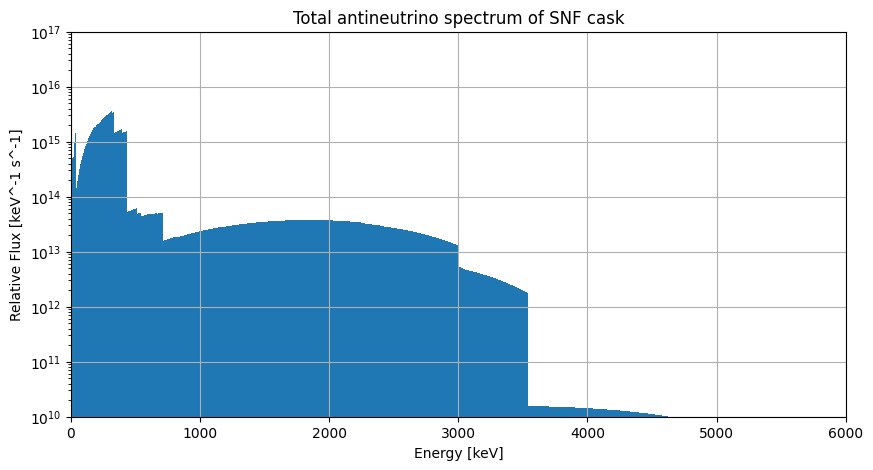

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Plot the spectrum
figure = plt.figure(figsize=(10, 5))
axes = figure.add_subplot(1, 1, 1)

axes.bar(
    x=total_spec.energy[:-1],
    height=total_spec.flux,
    width=np.diff(total_spec.energy),
)

axes.set_xlim(0, 6000)
axes.set_ylim(1e10, 1e17)
axes.set_xlabel("Energy [keV]")
axes.set_ylabel("Relative Flux [keV^-1 s^-1]")
axes.set_title(f"Total antineutrino spectrum of SNF cask")
axes.set_yscale("log")
axes.grid()

plt.show()

### Getting the spectrum for individual isotopes

If you want to get the individual spectra for each isotope in the cask, you can use the {py:func}`get_component_spectra <snf_simulations.cask.Cask.get_component_spectra>` method, which returns a list of `Spectrum` objects representing the antineutrino spectra for each isotope in the cask. For example:

In [12]:
cask = Cask.from_tabqfile('example.tbQ')
total_spec = cask.get_total_spectrum()
all_spec = cask.get_component_spectra()
for isotope_spec in all_spec:
    print(isotope_spec)

<Spectrum "Kr88": energy_range=(0.0-2918.0 keV)>
<Spectrum "Rb88": energy_range=(0.0-5312.4 keV)>
<Spectrum "Sr90": energy_range=(0.0-545.9 keV)>
<Spectrum "Y90": energy_range=(0.0-2278.5 keV)>
<Spectrum "Zr93": energy_range=(0.0-90.8 keV)>
<Spectrum "Tc99": energy_range=(0.0-297.5 keV)>
<Spectrum "Ru106": energy_range=(0.0-39.4 keV)>
<Spectrum "Rh106": energy_range=(0.0-3541.0 keV)>
<Spectrum "I129": energy_range=(0.0-149.4 keV)>
<Spectrum "Cs135": energy_range=(0.0-268.7 keV)>
<Spectrum "Cs137": energy_range=(0.0-1175.63 keV)>
<Spectrum "Ce144": energy_range=(0.0-318.7 keV)>
<Spectrum "Pr144": energy_range=(0.0-2997.5 keV)>
<Spectrum "Np239": energy_range=(0.0-714.6 keV)>
<Spectrum "Pu241": energy_range=(0.0-20.78 keV)>
<Spectrum "Am242": energy_range=(0.0-664.3 keV)>


We can also plot these to see how they contribute to the total spectrum:

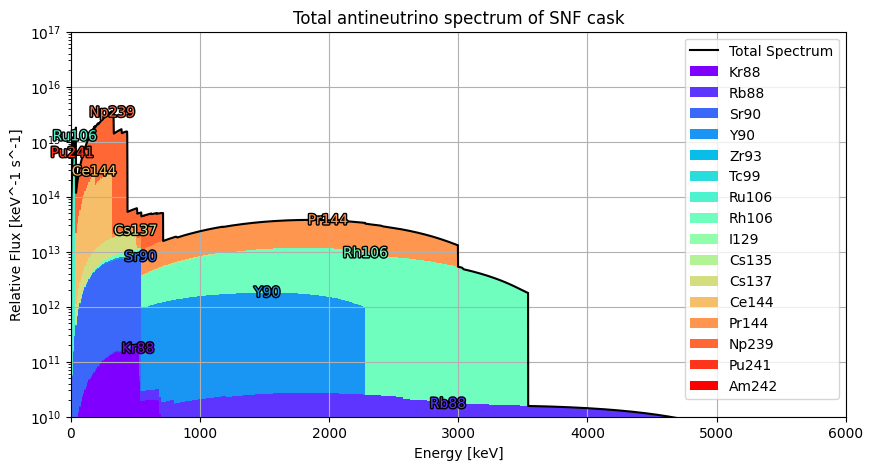

In [13]:
import matplotlib.patheffects as path_effects

figure = plt.figure(figsize=(10, 5))
axes = figure.add_subplot(1, 1, 1)

axes.plot(
    total_spec.energy[:-1],
    total_spec.flux,
    c="black",
    label="Total Spectrum",
)

colors = plt.get_cmap("rainbow")(np.linspace(0, 1, len(all_spec)))
bar_bottom = None
for isotope_spec, color in zip(all_spec, colors, strict=True):
    # Create a stacked bar plot for each isotope's contribution to the total spectrum
    isotope_spec.equalise(
        width=10,
        min_energy=0,
        max_energy=6000,
    )
    if bar_bottom is None:
        bar_bottom = np.zeros_like(isotope_spec.flux)
    axes.bar(
        x=isotope_spec.energy[:-1],
        height=isotope_spec.flux,
        width=np.diff(isotope_spec.energy),
        label=isotope_spec.name,
        bottom=bar_bottom,
        color=color,
    )

    # Add labels at the peak of each isotope's contribution
    peak_index = np.argmax(isotope_spec.flux-bar_bottom)
    if isotope_spec.flux[peak_index] > 0:
        text = axes.text(
            x=isotope_spec.energy[peak_index],
            y=(isotope_spec.flux+bar_bottom)[peak_index],
            s=str(isotope_spec.name),
            color=color,
            ha="center",
            va="center",
        )
        text.set_path_effects(
            [
                path_effects.Stroke(linewidth=2, foreground="black"),
                path_effects.Normal(),
            ]
        )

    bar_bottom += isotope_spec.flux

axes.legend()

axes.set_xlim(0, 6000)
axes.set_ylim(1e10, 1e17)
axes.set_xlabel("Energy [keV]")
axes.set_ylabel("Relative Flux [keV^-1 s^-1]")
axes.set_title(f"Total antineutrino spectrum of SNF cask")
axes.set_yscale("log")
axes.grid()

plt.show()

### Simulating the spectrum at different cooling times

We can also simulate the antineutrino spectrum after any given cooling time, which includes modeling the activity levels and decay chains.

The {py:func}`get_total_spectrum <snf_simulations.cask.Cask.get_total_spectrum>` method takes an optional `cooling_time` parameter, which specifies the time since the SNF was removed from the reactor, in years. 

For example we can plot the total spectrum for our cask after multiple different cooling times:

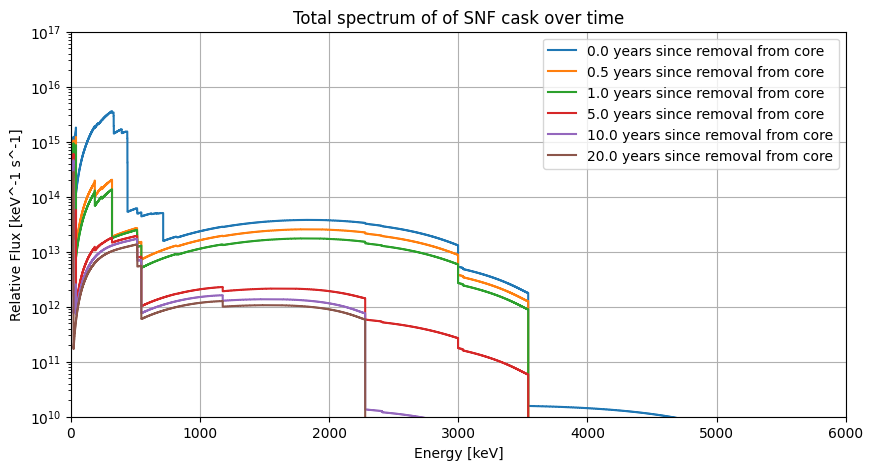

In [14]:
figure = plt.figure(figsize=(10, 5))
axes = figure.add_subplot(1, 1, 1)

initial_spec = cask.get_total_spectrum()
axes.step(
        initial_spec.energy[:-1],
        initial_spec.flux,
        where="post",
        label=f"0.0 years since removal from core",
    )

cooling_times = [0.5, 1, 5, 10, 20]
for cooling_time in cooling_times:
    total_spec = cask.get_total_spectrum(cooling_time=cooling_time)
    axes.step(
        total_spec.energy[:-1],
        total_spec.flux,
        where="post",
        label=f"{cooling_time:.1f} years since removal from core",
    )

axes.set_xlim(0, 6000)
axes.set_ylim(1e10, 1e17)
axes.set_xlabel("Energy [keV]")
axes.set_ylabel("Relative Flux [keV^-1 s^-1]")
axes.set_title(f"Total spectrum of of SNF cask over time")
axes.set_yscale("log")
axes.grid()
axes.legend()

plt.show()

:::{important}
You cannot simulate the spectrum for cooling times that are earlier than the initial cooling time specified when creating the `Cask` object.
:::

For example, here we specify the intial masses were simulated at 10 years after removal, so we cannot simulate the spectrum for cooling times less than 10 years:

In [15]:
file_content = (
    "*** TIME    1.000E+01 YEARS\n"
    "ALL-NUC      GRAMS\n"
    "SR90         10.0\n"
    "CS137        20.0\n"
    "TOTAL        30.0\n"
)

cask = Cask.from_tabqfile(file_content)
print(cask)

for cooling_time in [1, 5, 10, 20]:
    try:
        cask.get_total_spectrum(cooling_time=cooling_time)
        print(f"  Spectrum successfully simulated")
    except ValueError as e:
        print(f"  ValueError: {e}")

<Cask: 2 isotopes, cooling time=1.000e+01 years>
  ValueError: cooling_time (1.000e+00) cannot be less than the initial cask cooling time (1.000e+01)
  ValueError: cooling_time (5.000e+00) cannot be less than the initial cask cooling time (1.000e+01)
  Spectrum successfully simulated
  Spectrum successfully simulated
